In [29]:
from src.dataloading.epiconfig import EpiConfig
from src.dataloading.epidataorchestration import EpiDataOrchestrator
from src.dataloading.dataloaders import BaseLineDataLoaderManager, DeepDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel

In [3]:
cfghu= EpiConfig(
        disease         = 'chickenpox',
        country         = 'hungary',
        level           = 'nuts3',
        
        min_date        = '2005-01-01',
        max_date        = '2014-12-29',
        split_trainval  = '2013-01-01',
        split_valtest   = '2014-01-01',
        temporal_frequency= 'w',

        horizon_leadtime    = 4,

        sequence_length     = 4,
     
        log_transform       = ['incidence']
        )    

dataorchestrator_hu   = EpiDataOrchestrator(cfghu).build()

In [6]:
baseline_data           = BaseLineDataLoaderManager(dataorchestrator_hu)
constant_predictor      = ConstantModel(baseline_data)
persistence_predictor   = PersistenceModel(baseline_data)
climateology            = ClimateologyModel(baseline_data)
climascale              = ClimaScaleModel(baseline_data)

node_sample = 11

constant_predictor.set_model_hparams(0)
constant_predictor.train()
constant_predictor.forecast('test')

persistence_predictor.train()
persistence_predictor.forecast('test')

climateology.train()
climateology.forecast('test')

climascale.train()
climascale.forecast('test')

computing metrics nodewise:   0%|                                                                                                                                                      | 0/60 [00:00<?, ?it/s]

computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 150.87it/s]


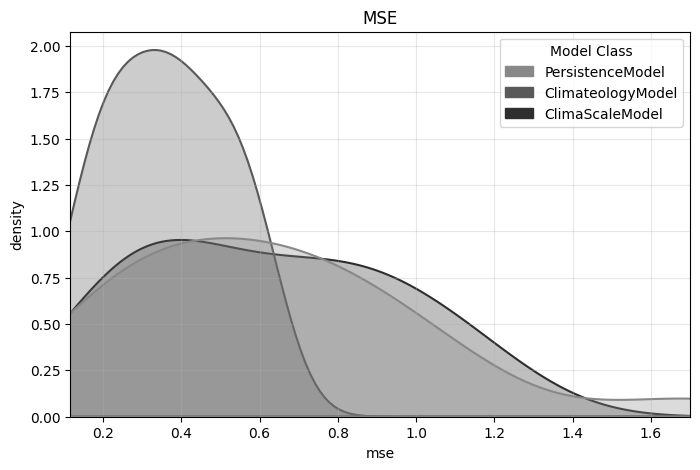

In [13]:
from src.evaluation import Evaluator
e = Evaluator([persistence_predictor, climateology, climascale]).add_evaluation(dataset = 'test')
e.plotter.plot_metric(0, 'test', 'mse', plot_type='kde', log = False, reverse_scale=True).show()

In [30]:
n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.2, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedataloader  = BaseLineDataLoaderManager(dataorchestrator_hu)
deepdataloader      = DeepDataLoaderManager(dataorchestrator_hu).build()
graphdataloader1    = GraphDataLoaderManager(dataorchestrator_hu).retrieve_static_graph('graph1').build()
graphdataloader2    = GraphDataLoaderManager(dataorchestrator_hu).retrieve_static_graph('graph2').build()

In [ ]:
from src.models import GCN2Model

# identity graph. self loops will be False
gcn1 = GCN2Model(graphdataloader1, name = 'gcn1', verbose = 2)
gcn1.set_model_hparams(dropout = 0.3, self_loops=False)
gcn1.set_global_hparams(**global_hparams)
gcn1.train()
gcn1.forecast('test')
gcn1.show_forecasts(26)


==                     gcn2                     ==
Dataloader:GraphDataList(411 datapoints, sample: x=(20, 3, 4), y=(20, 1), edge_index=(2, 82), edge_weight=(82,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.6844   |   0.4499   |    v     |           |
|  002  |   0.5054   |   0.4403   |    v     |           |
|  003  |   0.4764   |   0.4242   |    v     |           |
|  004  |   0.4608   |   0.4278   |          |   1/20    |
|  005  |   0.4424   |   0.4217   |    v     |           |
|  006  |   0.4380   |   0.4211   |    v     |           |
|  007  |   0.4241   |   0.4220   |          |   1/20    |
|  008  |   0.4326   |   0.4171   |    v     |           |
|  009  |   0.4327   |   0.4192   |          |   1/20    |


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel/training.py:218: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


|  010  |   0.4206   |   0.4170   |    v     |           |


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 52/52 [00:00<00:00, 320.30it/s]


Test loss: 0.4907


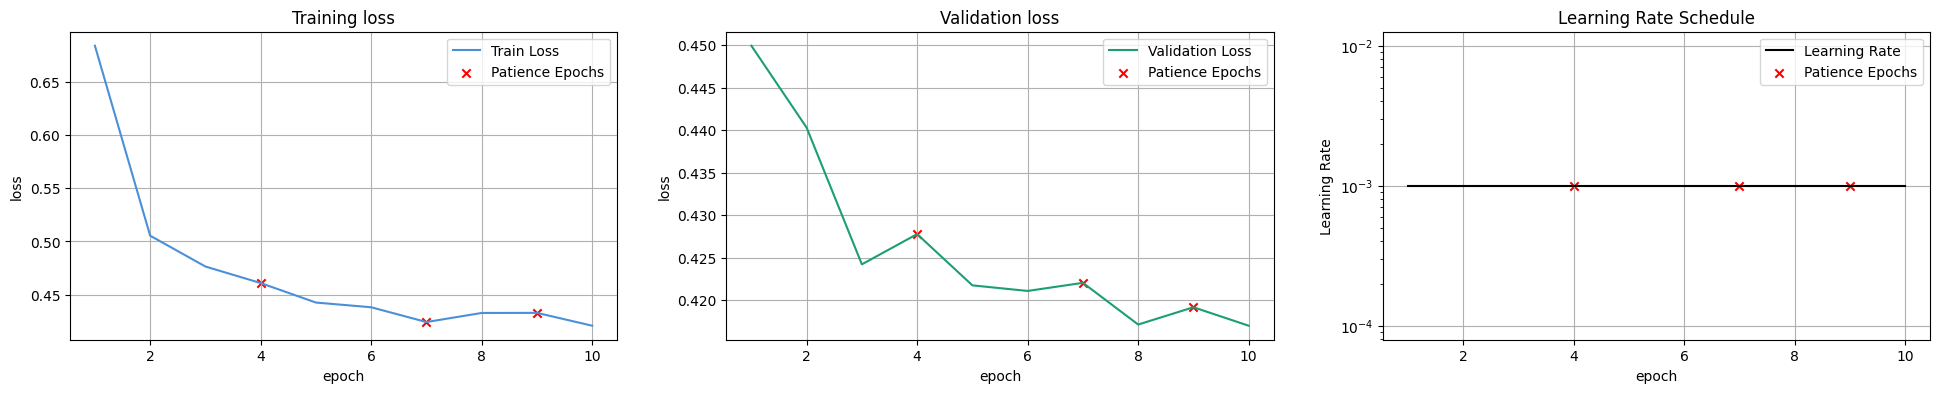

In [45]:
from src.models import GCN2Model

n_epochs        = 10
lr              = 0.001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.2, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

# identity graph. self loops will be False
gcn2 = GCN2Model(graphdataloader2, name = 'gcn2', verbose = 2)
gcn2.set_model_hparams(dropout = 0.3, self_loops=False, hidden_size=32)
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast('test')


computing metrics nodewise:   0%|                                                                                                                                                      | 0/80 [00:00<?, ?it/s]

computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 195.63it/s]


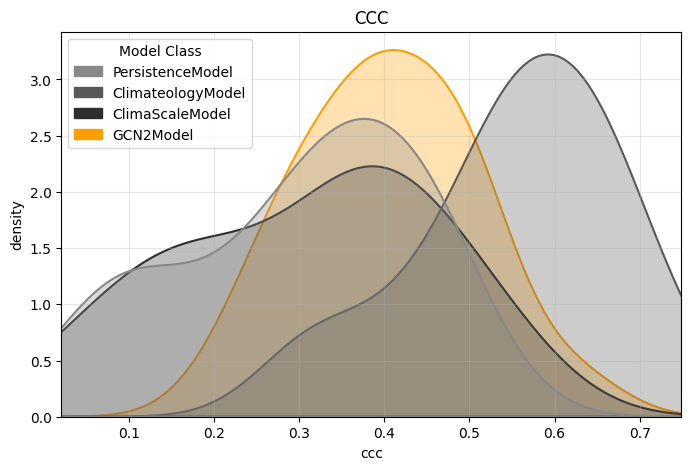

In [46]:
from src.evaluation import Evaluator
e = Evaluator([persistence_predictor, climateology, climascale, gcn2]).add_evaluation(dataset = 'test')
e.plotter.plot_metric(0, 'test', 'ccc', plot_type='kde', log = False, reverse_scale=True).show()

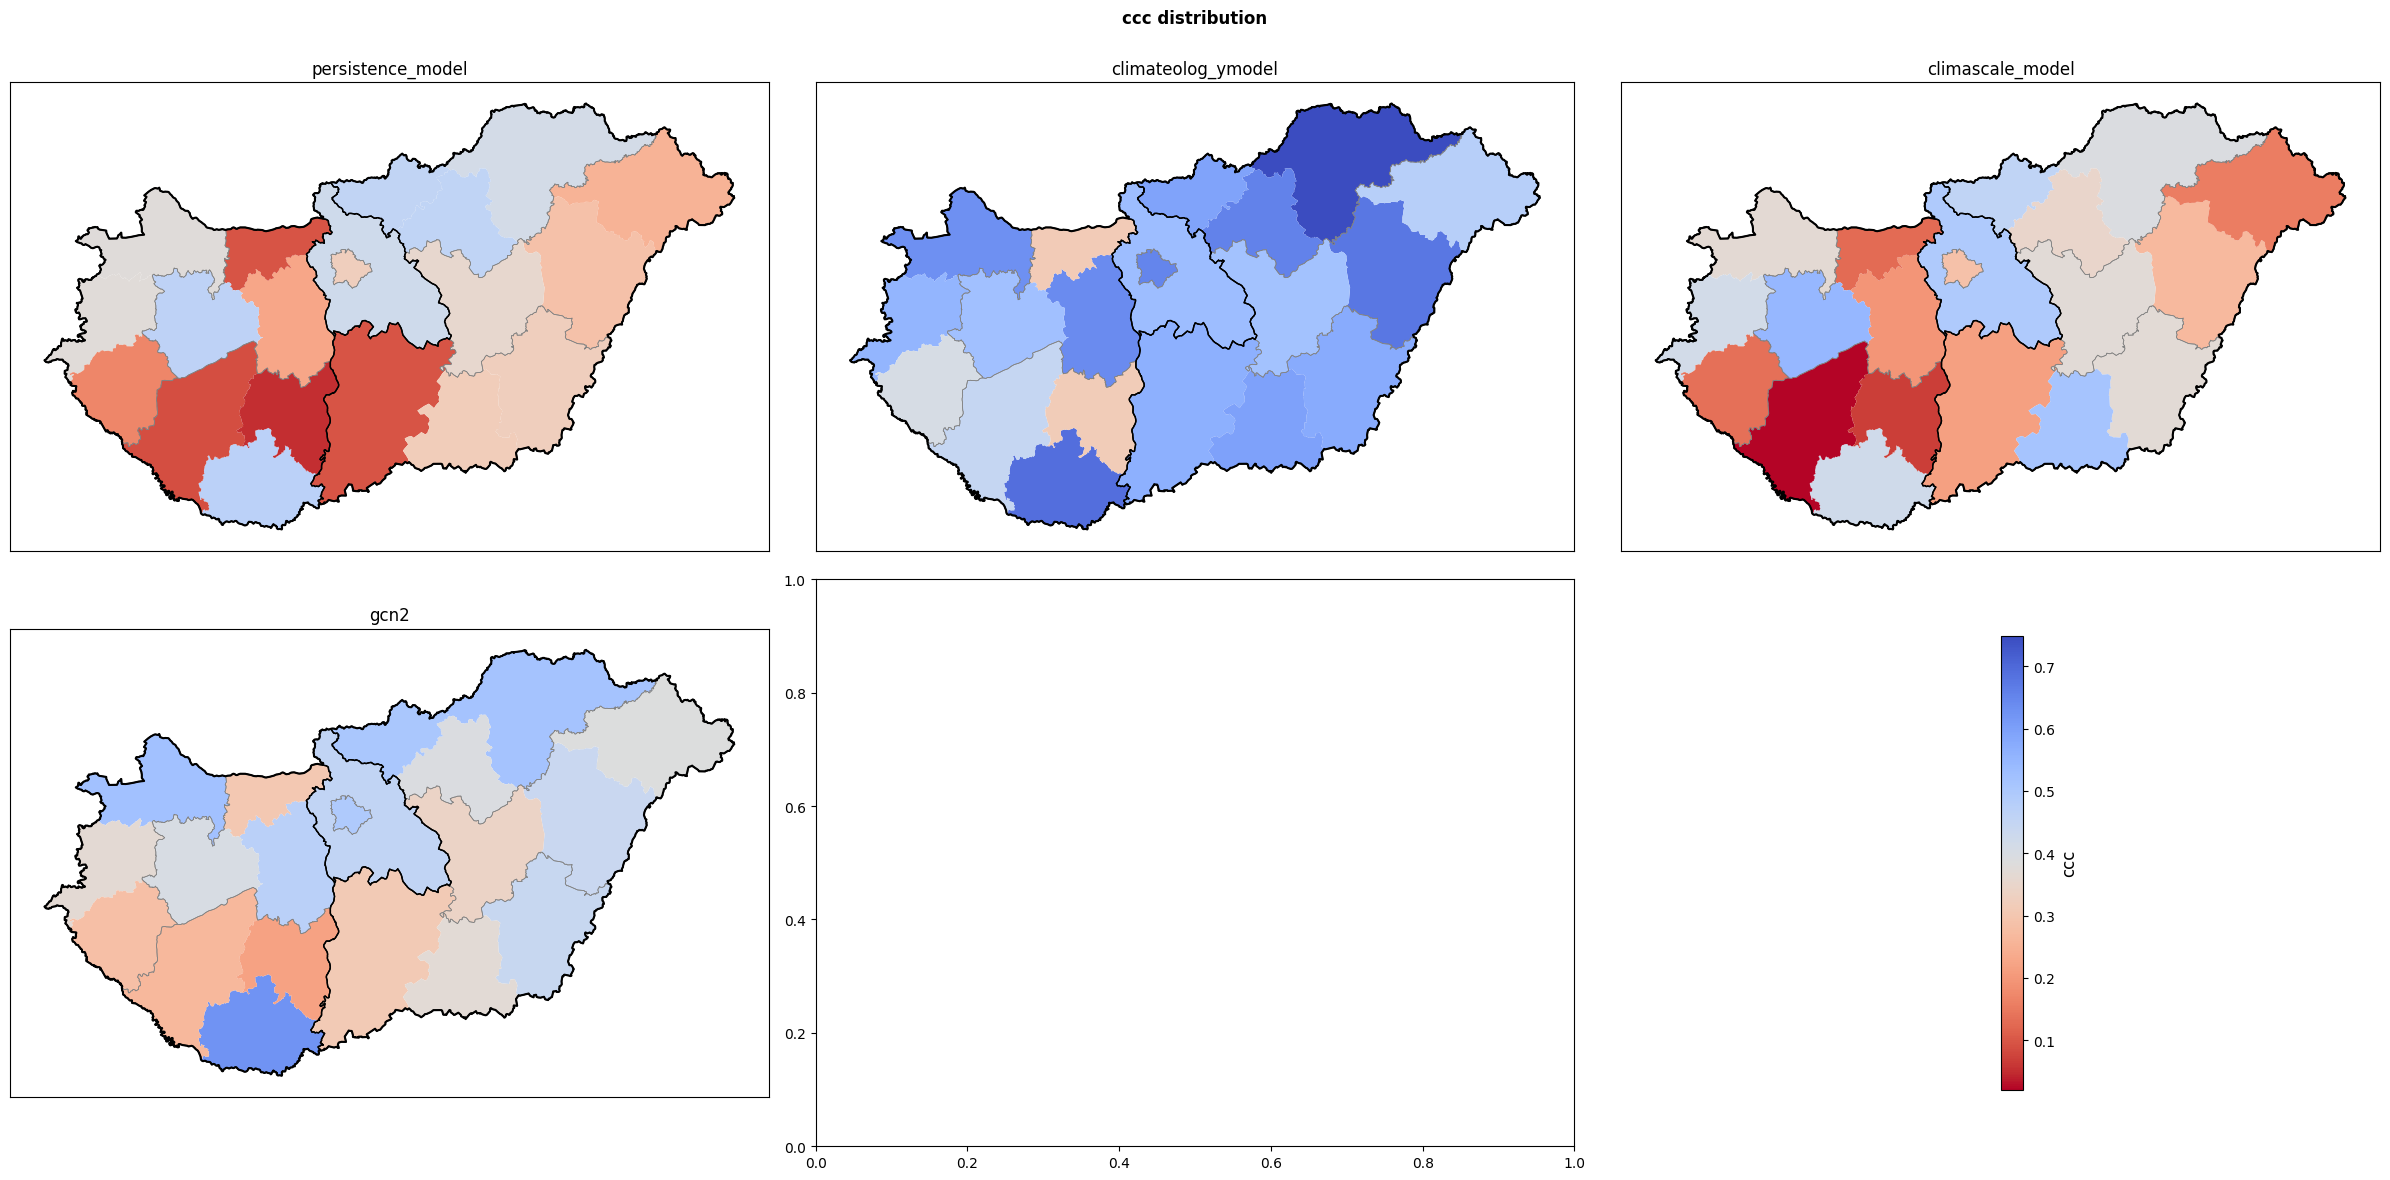

In [47]:
e.plotter.plot_metric(0, 'test', 'ccc', plot_type='map', log = False, reverse_scale=False).show()